# Tutustutaan aikasarjoihin (4.3.2026)

Tarkoituksena on seurailla melko tarkasti "Aikasarjojen kuvailua" -muistion sisältöä.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

# tyylimäärittely
sns.set_style("whitegrid")

## Tuodaan aineistot ja tutustutaan niihin

In [2]:
# tuodaan Yahoo Financesta tiedot:
fortum = yf.download("FORTUM.HE", start="2018-01-01", auto_adjust=True)
neste = yf.download("NESTE.HE", start="2018-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
fortum

Price,Close,High,Low,Open,Volume
Ticker,FORTUM.HE,FORTUM.HE,FORTUM.HE,FORTUM.HE,FORTUM.HE
Date,,,,,
2018-01-02,9.416202,9.464344,9.302924,9.351067,2117718
2018-01-03,9.475674,9.526649,9.424699,9.458683,1853210
2018-01-04,9.554968,9.583287,9.478505,9.515320,2036208
2018-01-05,9.577623,9.597447,9.509657,9.580456,1711840
2018-01-08,9.645590,9.733379,9.594615,9.600279,1973399
...,...,...,...,...,...
2026-02-26,19.540001,20.030001,19.504999,19.870001,1911176
2026-02-27,19.809999,20.059999,19.540001,19.580000,3513330


In [4]:
neste

Price,Close,High,Low,Open,Volume
Ticker,NESTE.HE,NESTE.HE,NESTE.HE,NESTE.HE,NESTE.HE
Date,,,,,
2018-01-02,14.049773,14.070844,13.865391,13.981288,1712055
2018-01-03,14.281567,14.302639,14.033970,14.039238,1895448
2018-01-04,14.060308,14.292100,13.728423,14.276295,3029775
2018-01-05,13.849588,14.018164,13.749496,14.012897,1923969
2018-01-08,14.413268,14.429072,13.802178,13.807447,2378901
...,...,...,...,...,...
2026-02-26,21.299999,21.370001,20.730000,21.360001,1145708
2026-02-27,21.180000,21.840000,21.120001,21.299999,3226638


## Aikasarjan kuvaaja

<Axes: xlabel='Date'>

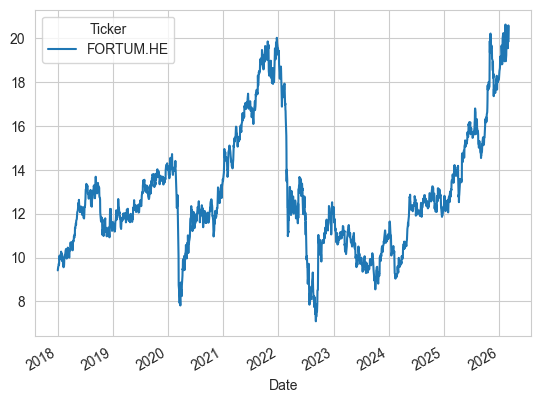

In [5]:
# yksinkertainen viivakaavio
fortum["Close"].plot()

<Axes: xlabel='Date'>

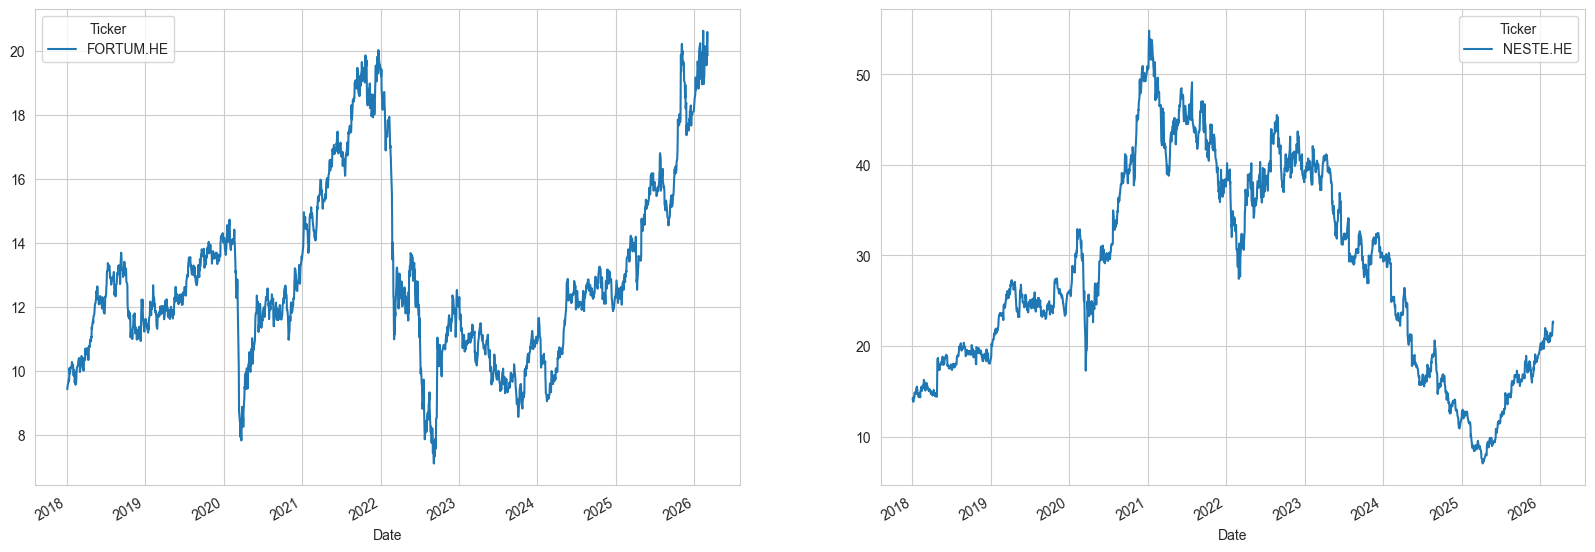

In [6]:
# vertaillaan Fortumia ja Nestettä. Tehdään kuva, jossa on kaksi vierekkäistä kaaviota.

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,7))
fortum["Close"].plot(ax=axs[0])
neste["Close"].plot(ax=axs[1])

<Axes: xlabel='Date'>

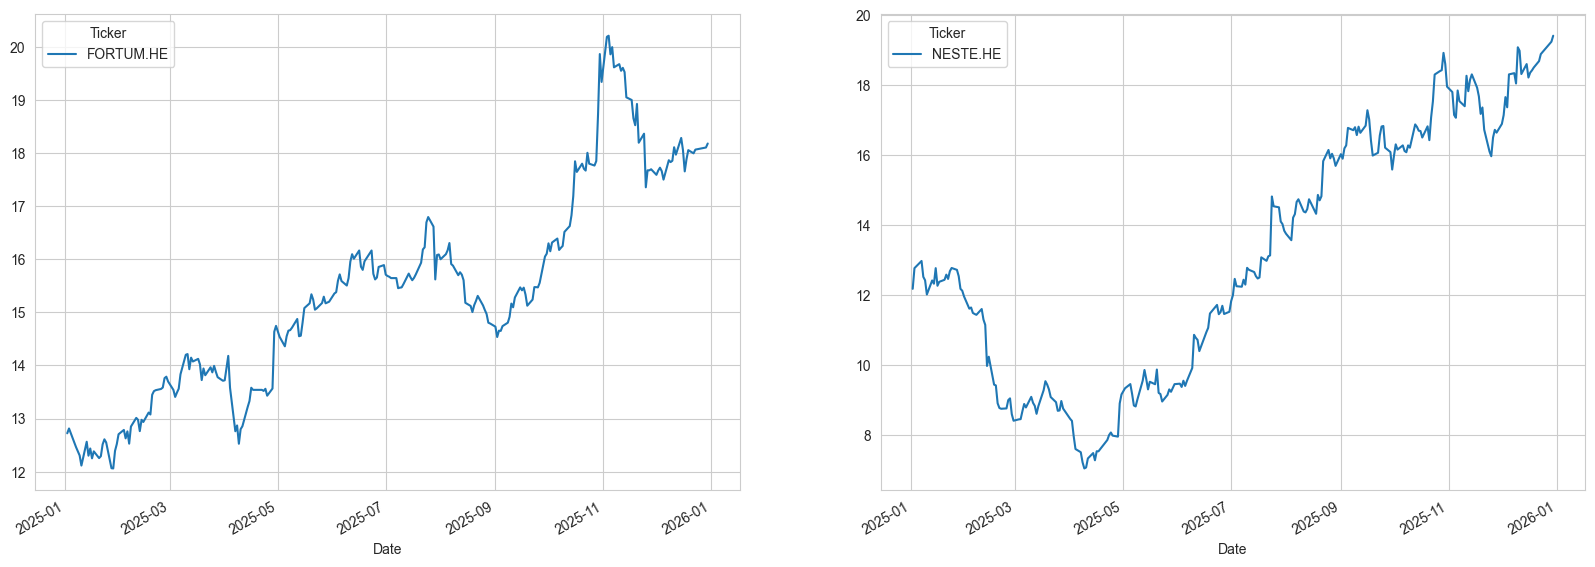

In [7]:
# vuosi 2025
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,7))
fortum["Close"]["2025":"2025"].plot(ax=axs[0])
neste["Close"]["2025":"2025"].plot(ax=axs[1])

<Axes: xlabel='Date'>

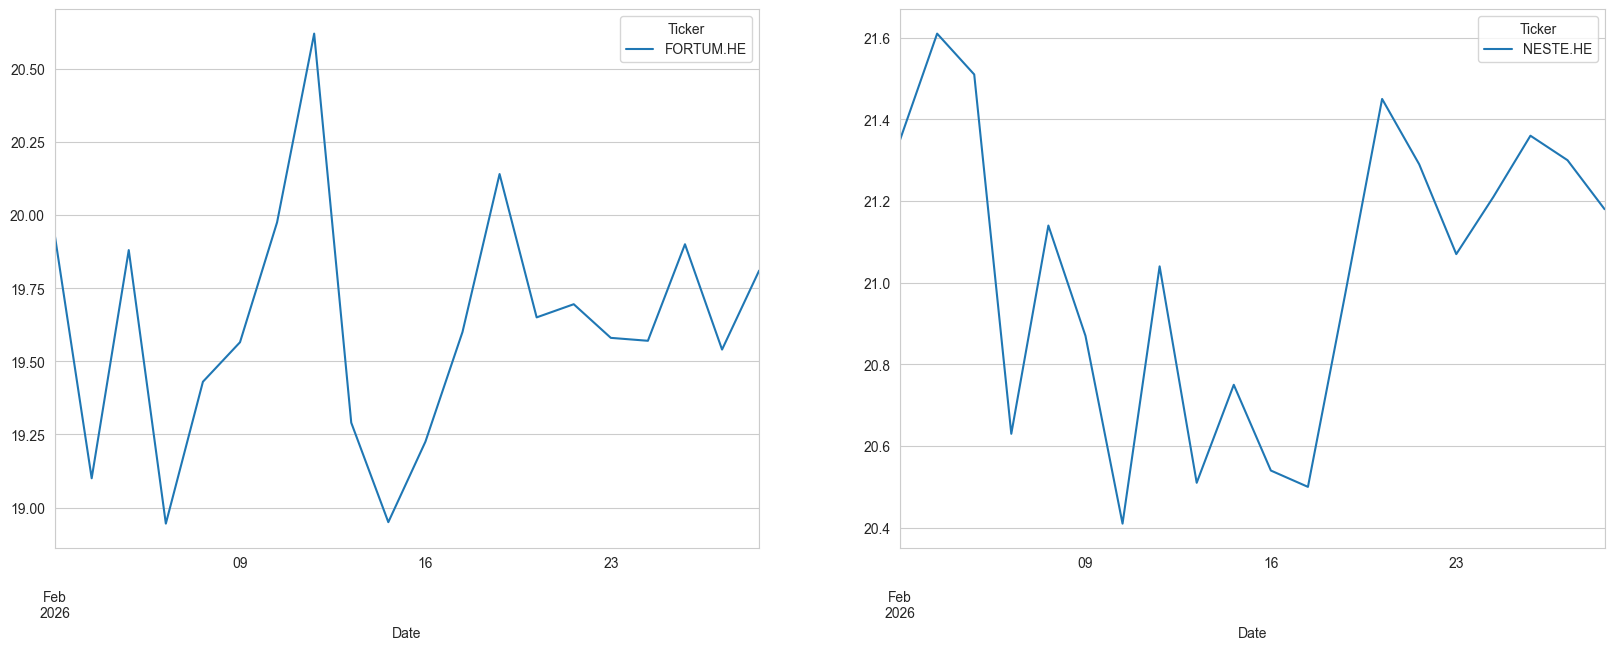

In [8]:
# helmikuu 2026
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,7))
fortum["Close"]["2026-02-01":"2026-02-28"].plot(ax=axs[0])
neste["Close"]["2026-02-01":"2026-02-28"].plot(ax=axs[1])

## Keskiarvoja ja summia

In [9]:
# esimerkki
fortum["Close"].resample("ME").mean()

Ticker,FORTUM.HE
Date,
2018-01-31,9.907415
2018-02-28,9.983582
2018-03-31,10.286819
2018-04-30,10.819735
2018-05-31,12.112549
...,...
2025-11-30,18.967000
2025-12-31,17.897632
2026-01-31,19.372000


<Axes: xlabel='Date'>

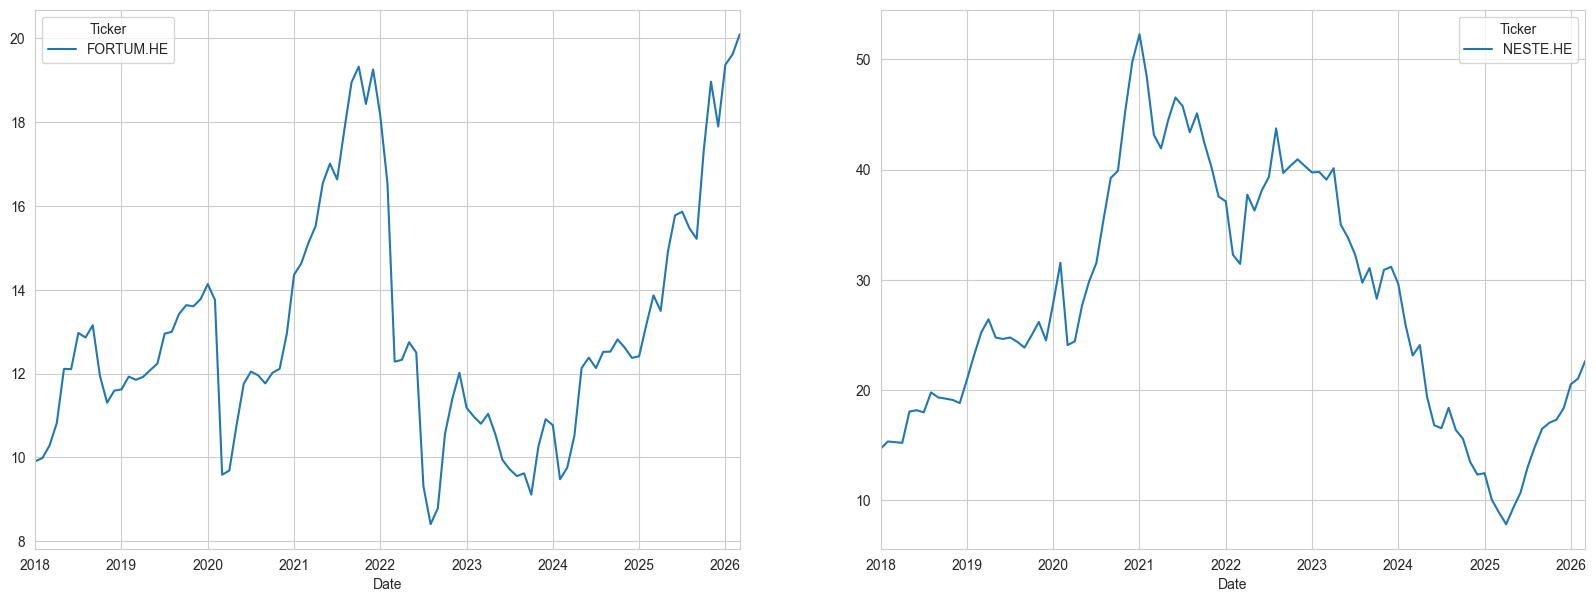

In [10]:
# päätöshintojen kuukausikohtaiset keskiarvot
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,7))
fortum["Close"].resample("ME").mean().plot(ax=axs[0])
neste["Close"].resample("ME").mean().plot(ax=axs[1])

(0.0, 220000000.0)

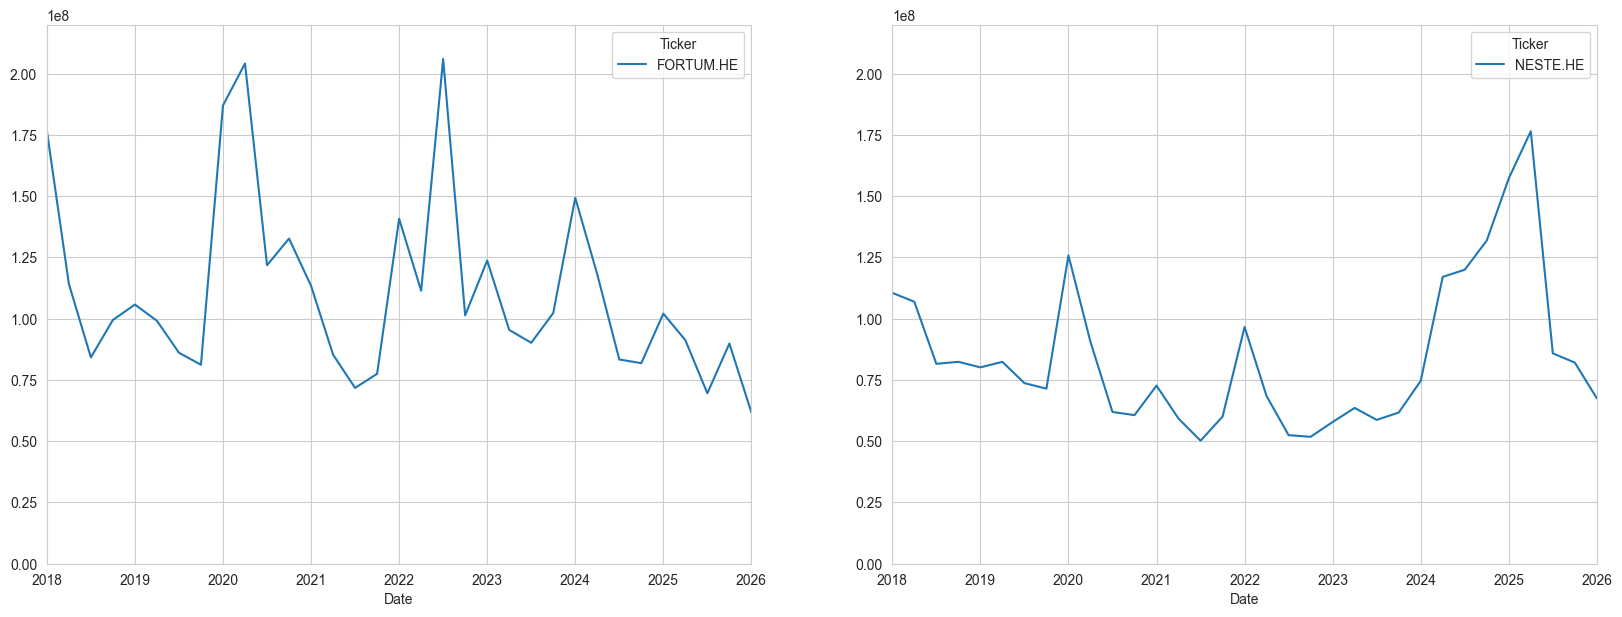

In [11]:
# lasketaa vaihdon konaismäärä neljännesvuositasolla
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,7))
fortum["Volume"].resample("QE").sum().plot(ax=axs[0])
neste["Volume"].resample("QE").sum().plot(ax=axs[1])
axs[0].set_ylim(0, 220_000_000)
axs[1].set_ylim(0, 220_000_000)

## Liukuvia keskiarvoja

In [12]:
# esimerkki
fortum['Close'].rolling(50).mean()

Ticker,FORTUM.HE
Date,
2018-01-02,NaN
2018-01-03,NaN
2018-01-04,NaN
2018-01-05,NaN
2018-01-08,NaN
...,...
2026-02-26,19.1678
2026-02-27,19.2018
2026-03-02,19.2540


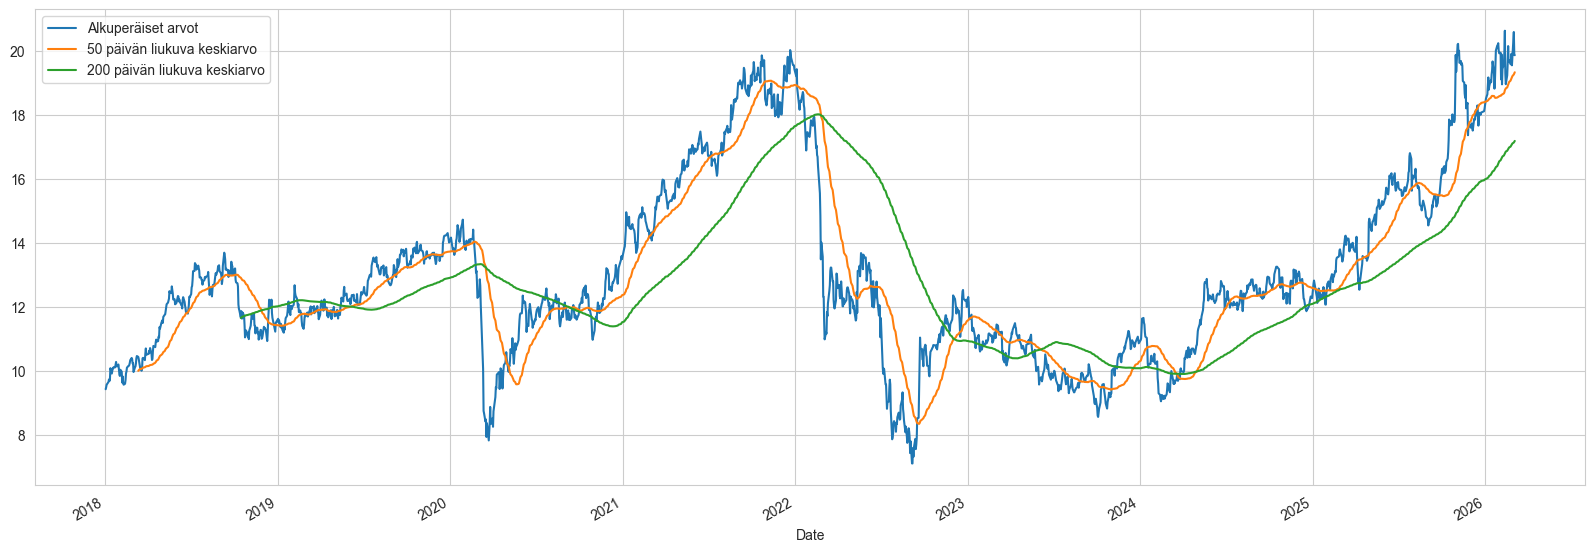

In [13]:
# piirretään samaan kuvaajaan erilaisia liukuvia keskiarvoja
fig, ax = plt.subplots(figsize=(20,7))

# alkuperäiset arvot
fortum["Close"].plot(ax=ax)

# liukuva keskiarvo (50 päivää)
fortum["Close"].rolling(50).mean().plot(ax=ax)

# liukuva keskiarvo (200 päivää)
fortum["Close"].rolling(200).mean().plot(ax=ax)

# selitelaatikko
plt.legend(["Alkuperäiset arvot", "50 päivän liukuva keskiarvo", "200 päivän liukuva keskiarvo"])

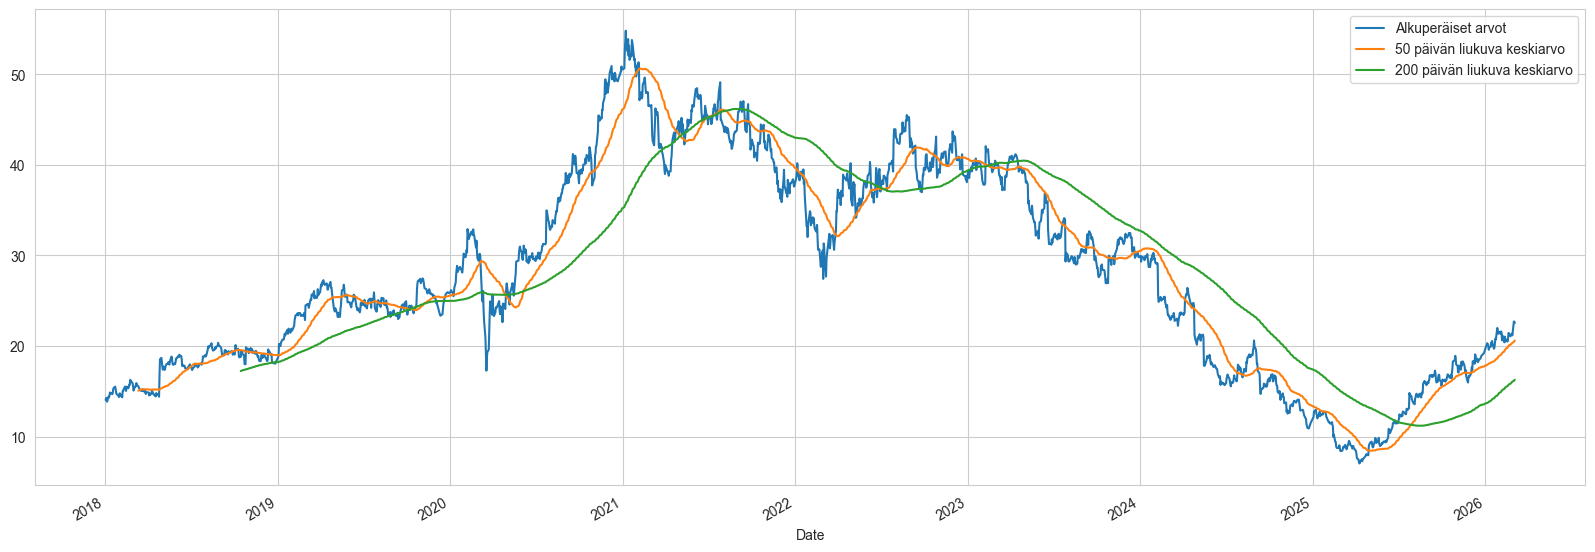

In [14]:
# piirretään samaan kuvaajaan erilaisia liukuvia keskiarvoja
fig, ax = plt.subplots(figsize=(20,7))

# alkuperäiset arvot
neste["Close"].plot(ax=ax)

# liukuva keskiarvo (50 päivää)
neste["Close"].rolling(50).mean().plot(ax=ax)

# liukuva keskiarvo (200 päivää)
neste["Close"].rolling(200).mean().plot(ax=ax)

# selitelaatikko
plt.legend(["Alkuperäiset arvot", "50 päivän liukuva keskiarvo", "200 päivän liukuva keskiarvo"])

## Muutosprosentit

In [15]:
# tarkastellaan päätöshintojen muutosprosentteja
fortum["fortum_muutos%"] = fortum["Close"].pct_change()*100
neste["neste_muutos%"] = neste["Close"].pct_change()*100

In [16]:
fortum

Price,Close,High,Low,Open,Volume,fortum_muutos%
Ticker,FORTUM.HE,FORTUM.HE,FORTUM.HE,FORTUM.HE,FORTUM.HE,
Date,,,,,,
2018-01-02,9.416202,9.464344,9.302924,9.351067,2117718,NaN
2018-01-03,9.475674,9.526649,9.424699,9.458683,1853210,0.631593
2018-01-04,9.554968,9.583287,9.478505,9.515320,2036208,0.836819
2018-01-05,9.577623,9.597447,9.509657,9.580456,1711840,0.237107
2018-01-08,9.645590,9.733379,9.594615,9.600279,1973399,0.709638
...,...,...,...,...,...,...
2026-02-26,19.540001,20.030001,19.504999,19.870001,1911176,-1.809039
2026-02-27,19.809999,20.059999,19.540001,19.580000,3513330,1.381773


In [17]:
neste

Price,Close,High,Low,Open,Volume,neste_muutos%
Ticker,NESTE.HE,NESTE.HE,NESTE.HE,NESTE.HE,NESTE.HE,
Date,,,,,,
2018-01-02,14.049773,14.070844,13.865391,13.981288,1712055,NaN
2018-01-03,14.281567,14.302639,14.033970,14.039238,1895448,1.649802
2018-01-04,14.060308,14.292100,13.728423,14.276295,3029775,-1.549264
2018-01-05,13.849588,14.018164,13.749496,14.012897,1923969,-1.498681
2018-01-08,14.413268,14.429072,13.802178,13.807447,2378901,4.070010
...,...,...,...,...,...,...
2026-02-26,21.299999,21.370001,20.730000,21.360001,1145708,-0.280905
2026-02-27,21.180000,21.840000,21.120001,21.299999,3226638,-0.563375


In [19]:
# muodostetaan uusi dataframe, jossa on muutosprosentit
muutokset = pd.concat([fortum["fortum_muutos%"], neste["neste_muutos%"]], axis=1)

# korvataan puuttuvat arvot nollilla
muutokset = muutokset.fillna(0)

muutokset

,fortum_muutos%,neste_muutos%
Date,,
2018-01-02,0.000000,0.000000
2018-01-03,0.631593,1.649802
2018-01-04,0.836819,-1.549264
2018-01-05,0.237107,-1.498681
2018-01-08,0.709638,4.070010
...,...,...
2026-02-26,-1.809039,-0.280905
2026-02-27,1.381773,-0.563375
2026-03-02,3.886928,7.082153


<Axes: xlabel='Date'>

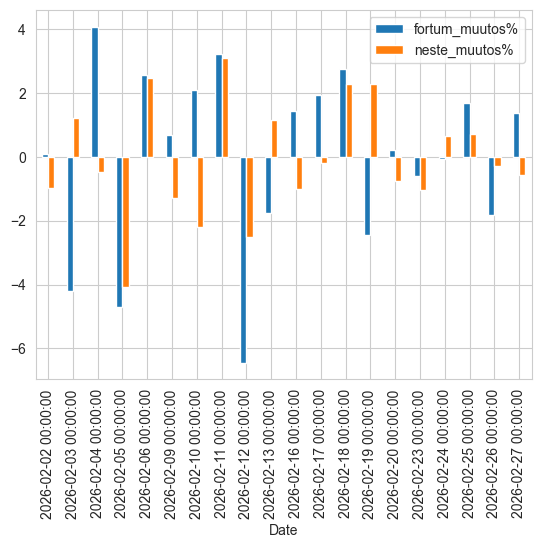

In [20]:
# vilkaisetaan visuaalisesti helmikuu 2026 muutosprosentteja
muutokset.loc["2026-02"].plot(kind="bar")

In [21]:
# tunnuslukuja muutosprosenteista
muutokset.describe().round(2)

,fortum_muutos%,neste_muutos%
count,2052.00,2052.00
mean,0.05,0.05
std,1.92,2.43
min,-13.07,-14.88
25%,-0.87,-1.19
50%,0.11,0.00
75%,1.04,1.29
max,11.07,16.83


<Axes: >

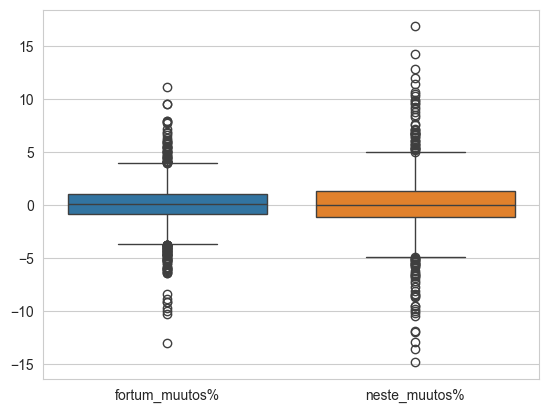

In [22]:
# suunnilleen sama laatikkojanakuviolla
sns.boxplot(data=muutokset)

In [26]:
# poimitaan suuret muutokset
muutokset[(abs(muutokset['fortum_muutos%'])>10) | (abs(muutokset['neste_muutos%'])>10)]

,fortum_muutos%,neste_muutos%
Date,,
2018-04-26,2.943596,16.827632
2018-04-27,-0.423605,10.238472
2018-10-26,1.162173,10.469305
2020-03-09,-10.029042,-11.968545
2020-03-12,-13.073776,-8.141766
2020-07-23,0.768397,11.374017
2022-03-01,-9.182584,-10.261510
2022-03-02,-0.029238,14.254028
2022-04-29,-0.407147,-10.043681


In [27]:
# muutosten korrelaatio
muutokset.corr()

,fortum_muutos%,neste_muutos%
fortum_muutos%,1.000000,0.313562
neste_muutos%,0.313562,1.000000


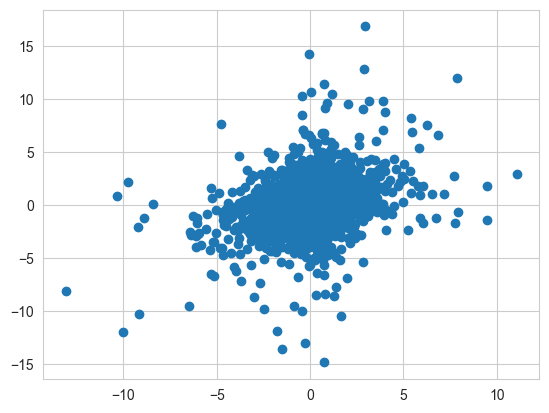

In [28]:
# tarkastellaan tätä vielä hajontakuviolla
plt.scatter(muutokset["fortum_muutos%"], muutokset["neste_muutos%"])

<Axes: xlabel='Date'>

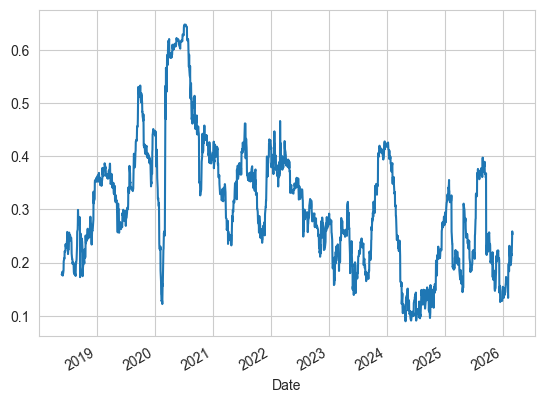

In [29]:
# tarkastellaan liukuvaa korrelaatiota
muutokset["fortum_muutos%"].rolling(100).corr(muutokset["neste_muutos%"]).plot()

## Osakkeisiin liittyvä riski eli volatiliteetti

<Axes: xlabel='Date'>

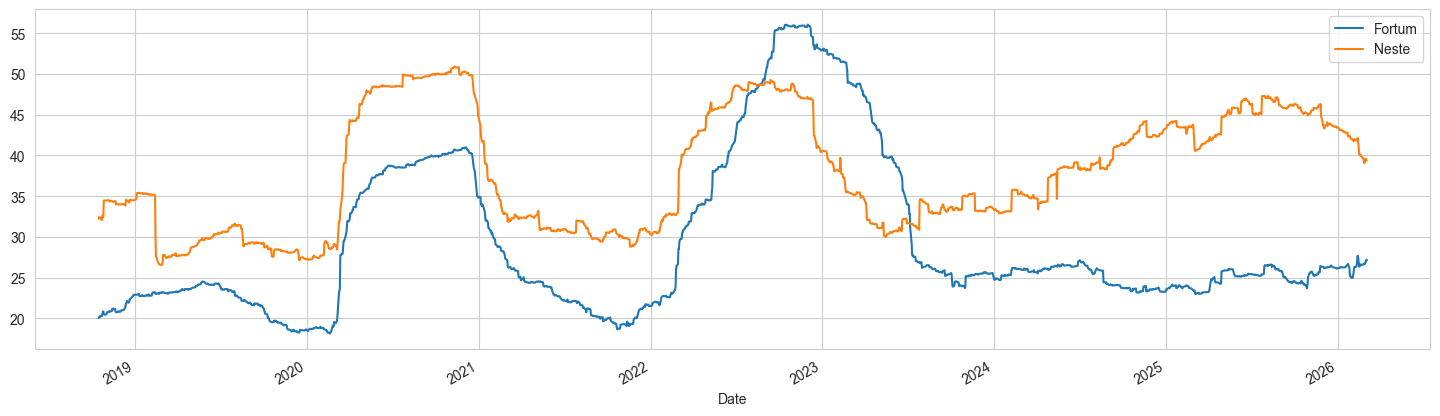

In [31]:
# lasketaan 200 päivän liukuva volatiliteetti
plt.figure(figsize=(18,5))
(muutokset['fortum_muutos%'].rolling(200).std()*(252**0.5)).plot(label="Fortum", legend=True)
(muutokset['neste_muutos%'].rolling(200).std()*(252**0.5)).plot(label="Neste", legend=True)